# TESTING - Random search algorithm

In [1]:
METHOD = "RANDOM"

In [2]:
import io
import os
import random
import torch
import json
import contextlib
from ultralytics import YOLO 
from mylib import simsettings
from mylib import myutils
from mylib import simtools
from mylib import yolo_patch_softmax as _
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER_COEF, CONFIDENCE_THRESHOLD, LOCATION_ERROR_THRESHOLD, PSEUDO_COUNT_THRESHOLD
from constants import ACTIONS   
from constants import NUM_EPOCHS
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")  

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

PluginManager::Manager: duplicate static plugin StbImageImporter, ignoring
PluginManager::Manager: duplicate static plugin GltfImporter, ignoring
PluginManager::Manager: duplicate static plugin BasisImporter, ignoring
PluginManager::Manager: duplicate static plugin AssimpImporter, ignoring
PluginManager::Manager: duplicate static plugin AnySceneImporter, ignoring
PluginManager::Manager: duplicate static plugin AnyImageImporter, ignoring


In [4]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration (index selects the simulation)
simulation = simulations[56]

# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]
INDEX = simulation["index"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

In [5]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()

# Define navmesh settings
navmesh_settings = simsettings.create_navmesh_settings(AGENT_HEIGHT, AGENT_RADIUS, max_climb=0.2, max_slope=45.0, include_static_objects=True)

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the top-down map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map, topdown_resolution = myutils.process_raw_topdown_map(topdown_map)

# Generate the coarse map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map, grid_resolution = myutils.process_raw_grid_map(grid_map, sim.pathfinder)

# Find free cells in the grid map
grid_free_cells, map_free_cells, world_free_coords = myutils.find_free_cells(grid_map, grid_resolution, topdown_map, topdown_resolution, sim.pathfinder)
num_free_cells = len(grid_free_cells)

In [6]:
starting_grid_positions = []
starting_orientations = []

for _ in range(NUM_EPOCHS):
    # Randomly select a free cell
    starting_grid_positions.append(random.choice(grid_free_cells))
    starting_orientations.append(random.choice([0, 90, 180, 270])) # Random orientation in degrees

# Print it like it was a list
print("starting_grid_positions = [", end="")
for pos in starting_grid_positions:
    print(f"{pos}, ", end="")
print("]")

print("starting_orientations = [", end="")
for ori in starting_orientations:
    print(f"{ori}, ", end="")
print("]")

starting_grid_positions = [[22, 19], [10, 33], [37, 16], [9, 39], [21, 28], [24, 25], [11, 36], [3, 8], [21, 17], [14, 13], [33, 10], [38, 40], [34, 14], [4, 36], [5, 5], [5, 22], [32, 19], [1, 27], [14, 27], [22, 32], [35, 38], [22, 17], [7, 2], [31, 21], [21, 24], [3, 4], [24, 11], [8, 31], [14, 20], [41, 37], [12, 43], [8, 5], [8, 8], [35, 35], [36, 29], [18, 25], [6, 32], [9, 21], [36, 31], [8, 37], [18, 39], [39, 34], [36, 11], [37, 30], [39, 34], [37, 22], [37, 11], [12, 35], [35, 29], [3, 8], [21, 36], [15, 29], [8, 16], [6, 28], [5, 14], [9, 25], [20, 19], [8, 18], [9, 8], [19, 33], [12, 15], [2, 26], [35, 17], [3, 23], [6, 14], [24, 6], [6, 32], [33, 33], [18, 42], [2, 21], [23, 10], [23, 5], [4, 21], [42, 43], [36, 36], [44, 42], [14, 39], [30, 16], [32, 40], [5, 17], [4, 7], [20, 33], [9, 20], [7, 19], [4, 2], [30, 12], [38, 40], [14, 27], [16, 16], [18, 32], [35, 7], [29, 23], [31, 13], [20, 39], [19, 26], [18, 19], [32, 14], [8, 1], [3, 16], [33, 21], ]
starting_orientatio

In [7]:
starting_grid_positions = [[42, 39]]
starting_orientations = [90]


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math
import numpy as np

transversed_cells = []

In [8]:
# Epochs metrics
num_actions_epochs = []
travelled_distance_epochs = []
success_epochs = []
location_error_epochs = []

In [9]:
for index, (GRID_POSITION, AGENT_YAW) in enumerate(zip(starting_grid_positions, starting_orientations)):

    # Initialize an agent
    agent = sim.initialize_agent(sim_settings["default_agent"])

    # Sample a random position (within the possible ones)
    grid_position = GRID_POSITION
    idx = grid_free_cells.index(grid_position)
    world_position = world_free_coords[idx]
    map_position = map_free_cells[idx]

    # Sample a random yaw rotation
    agent_yaw = AGENT_YAW  # in degrees
    agent_quart = myutils.yaw_to_quaternion(agent_yaw)

    # Set agent state
    agent_state = habitat_sim.AgentState()
    agent_state.position = world_position
    agent_state.rotation = agent_quart
    agent.set_state(agent_state)

    # Compute agent radius in both maps
    min_bounds, max_bounds = sim.pathfinder.get_bounds()
    x_dim = max_bounds[0] - min_bounds[0]
    topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
    grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

    # Get initial agent position tuple and radius tuple
    agent_radius = (topdown_radius, grid_radius)
    agent_positions = (map_position, grid_position)

    # Get initial observations and maps
    observations = sim.get_sensor_observations(0)
    rgb = observations["color_sensor"]
    depth = observations["depth_sensor"]

    # Display the initial simulation state (maps + observations)
    print(f"\n\nSimulation {index}/{len(starting_grid_positions)}")
    #simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

    # Metrics initialization
    target_found = False
    num_actions = 0
    travelled_distance = 0.0
    location_error = float("inf")

    # Simulation parameters
    MAX_ITER = int(num_free_cells * MAX_ITER_COEF)/4  # Maximum number of actions to perform

    # Plot occupancy grid with robot position
    plt.figure(figsize=(12,12))
    ax2 = plt.gca()
    ax2.imshow(grid_map)
    # Black grid lines
    rows, cols = grid_map.shape[:2]
    for i in range(rows):
        ax2.axhline(y=i-0.5, color='black', linewidth=0.5)
    for j in range(cols):
        ax2.axvline(x=j-0.5, color='black', linewidth=0.5)

    # Draw the agent position and orientation on the top-down map and occupancy grid
    grid_x, grid_y = grid_position
    ax2.add_patch(plt.Circle((grid_y, grid_x), grid_radius*2/3, color="red", fill=True))
    ax2.add_patch(plt.Arrow(grid_y, grid_x, -grid_radius * np.sin(math.radians(agent_yaw)), -grid_radius * np.cos(math.radians(agent_yaw)), width=grid_radius / 2, color="black"))

    # Save figure
    plt.savefig(f"outputs/image_{num_actions}.png")
    plt.close()

    transversed_cells.append(grid_position)


    # Main simulation loop
    while (num_actions < MAX_ITER) and (not target_found):

        # Select an action randomly
        action = random.choice(list(ACTIONS))
        num_actions += 1

        # Check if the action is valid
        if not simtools.is_action_valid(action, grid_position, agent_yaw, grid_free_cells):
            continue 
        
        # Perform the action and update agent state
        grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
        
        # Update the agent position and orientation
        idx = grid_free_cells.index(grid_position)
        map_position, world_position = map_free_cells[idx], world_free_coords[idx]
        agent_quart = myutils.yaw_to_quaternion(agent_yaw)
        agent_positions = (map_position, grid_position)

        # Compute travelled distance
        travelled_distance += simtools.compute_travelled_distance(agent_state.position, world_position)

        # Set agent state
        agent_state.position = world_position
        agent_state.rotation = agent_quart
        agent.set_state(agent_state)

        # Get observations
        obs = sim.get_sensor_observations(0)
        rgb, depth = obs["color_sensor"], obs["depth_sensor"]

        # YOLO Prediction
        results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
        detections = simtools.parse_yolo_detections(results)
        simtools.merge_rgb_yolo_outputs(rgb, detections)
        target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
        
        
        # Plot occupancy grid with robot position
        plt.figure(figsize=(12,12))
        ax2 = plt.gca()
        ax2.imshow(grid_map)
        # Black grid lines
        rows, cols = grid_map.shape[:2]
        for i in range(rows):
            ax2.axhline(y=i-0.5, color='black', linewidth=0.5)
        for j in range(cols):
            ax2.axvline(x=j-0.5, color='black', linewidth=0.5)

        # Draw the agent position and orientation on the top-down map and occupancy grid
        grid_x, grid_y = grid_position
        ax2.add_patch(plt.Circle((grid_y, grid_x), grid_radius*2/3, color="red", fill=True))
        ax2.add_patch(plt.Arrow(grid_y, grid_x, -grid_radius * np.sin(math.radians(agent_yaw)), -grid_radius * np.cos(math.radians(agent_yaw)), width=grid_radius / 2, color="black"))

        # Save figure
        plt.savefig(f"outputs/image_{num_actions}.png")
        plt.close()

        transversed_cells.append(grid_position)


    # Compute the target location if it was found
    if target_found:
        # Real world position
        center_x, center_y = simtools.get_box_center(target_bbox)
        depth_value = depth[center_y, center_x]
        target_location = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)

    # Evaluating correctness of the target detection
    if target_found:
        # Location error
        location_error = simtools.compute_location_error(target_location, REAL_TARGET_LOCATION)

        # Compare with threshold
        if location_error > LOCATION_ERROR_THRESHOLD:
            print(f"\nLocation error {location_error:.3f} m exceeds threshold {LOCATION_ERROR_THRESHOLD} m. FAILURE!")
            target_found = False

        # Plot maps with target
        target_positions = simtools.get_2d_coords(target_location, topdown_resolution, grid_resolution, sim.pathfinder)
        real_target_positions = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
        simtools.display_sim_observations(rgb, depth)
        simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_positions, real_target_positions)

    # Display simulation result and metrics
    if target_found:
        print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
        print(f"Found location: {target_location}")
    else:
        print(f"\nTarget object <{TARGET_OBJECT}> not found after {num_actions} actions!")

    print(f"Ground-truth location: {REAL_TARGET_LOCATION}")
    print(f"Number of actions: {num_actions}")
    print(f"Travelled distance: {travelled_distance:.2f} m")
    print(f"Computed location error: {location_error:.3f} m")

    # Store metrics
    num_actions_epochs.append(num_actions)
    travelled_distance_epochs.append(travelled_distance)
    success_epochs.append(target_found)
    location_error_epochs.append(location_error)




Simulation 0/1

Target object <laptop> not found after 238 actions!
Ground-truth location: [-7.045173147693276, 0.7598282077372184, 7.060832977294988]
Number of actions: 238
Travelled distance: 20.97 m
Computed location error: inf m


In [11]:
# Make sure OpenCV is installed:  pip install opencv-python

import cv2
import os

input_dir = "outputs"           # folder containing image_0.png ... image_213.png
output_video = "images_only.mp4"
fps = 5
extra_seconds_at_end = 3
extra_frames = extra_seconds_at_end * fps   # 210 frames

# Collect all valid image_i.png files
frames = []
i = 0
while True:
    path = os.path.join(input_dir, f"image_{i}.png")
    if not os.path.exists(path):
        break
    frames.append(path)
    i += 1

if not frames:
    raise RuntimeError("No image_i.png files detected!")

# Determine frame size from first image
img = cv2.imread(frames[0])
h, w, _ = img.shape
frame_size = (w, h)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(output_video, fourcc, fps, frame_size)

# Write all frames
for path in frames:
    frame = cv2.imread(path)
    frame = cv2.resize(frame, (w, h))
    writer.write(frame)

# Hold the final frame for 7 seconds
last_frame = cv2.imread(frames[-1])
last_frame = cv2.resize(last_frame, (w, h))
for _ in range(extra_frames):
    writer.write(last_frame)

writer.release()
print(f"✅ Done — wrote {len(frames)} frames + {extra_frames} frozen, to {output_video} at {fps} fps")

✅ Done — wrote 34 frames + 15 frozen, to images_only.mp4 at 5 fps


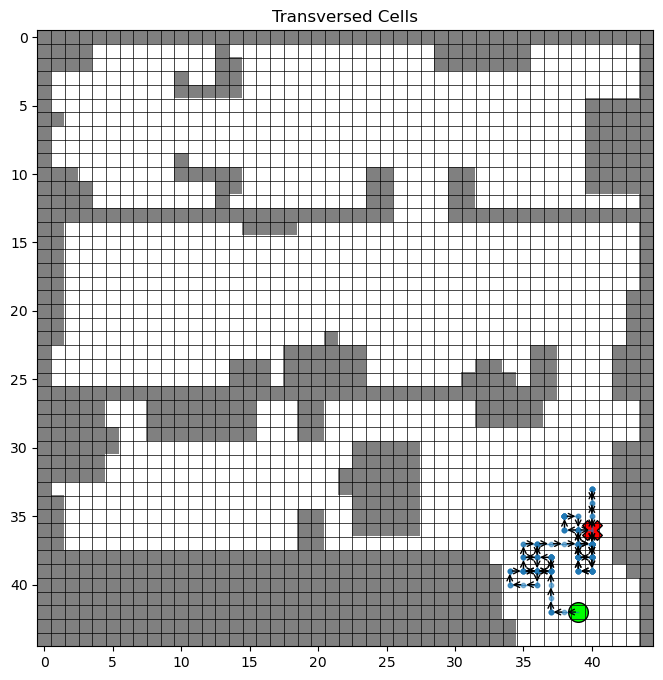

In [12]:
plt.figure(figsize=(8,8))
ax = plt.gca()
ax.imshow(grid_map)

# Black grid lines
rows, cols = grid_map.shape[:2]
for i in range(rows):
    ax.axhline(y=i-0.5, color='black', linewidth=0.5)
for j in range(cols):
    ax.axvline(x=j-0.5, color='black', linewidth=0.5)

# Plot transversed cells
if transversed_cells:
    x_coords, y_coords = zip(*transversed_cells)

    # normal path points
    ax.scatter(y_coords, x_coords, s=10, alpha=0.5)

    # trajectory direction (line)
    ax.plot(y_coords, x_coords, linewidth=1, alpha=0.7)

    # highlight start + end
    ax.scatter(y_coords[0], x_coords[0], s=200, marker='o', edgecolor='black', facecolor='lime', label='start')
    ax.scatter(y_coords[-1], x_coords[-1], s=200, marker='X', edgecolor='black', facecolor='red', label='end')

    # optional arrows between each step (uncomment if you want them)
    for (x1,y1), (x2,y2) in zip(transversed_cells[:-1], transversed_cells[1:]):
        ax.annotate('', xy=(y2,x2), xytext=(y1,x1), arrowprops=dict(arrowstyle='->', lw=1))

ax.set_title('Transversed Cells')
plt.savefig("outputs/transversed_cells.png")

In [ ]:
import numpy as np

# Pre-process
num_actions_epochs = np.array(num_actions_epochs)
travelled_distance_epochs = np.array(travelled_distance_epochs)
success_epochs = np.array(success_epochs)
location_error_epochs = np.array(location_error_epochs)

# Counting
num_total_epochs = len(num_actions_epochs)
num_success_epochs = np.sum(success_epochs)

# Metrics on all runs
total_avg_num_actions = np.sum(num_actions_epochs) / num_total_epochs
total_avg_tavelled_distance = np.sum(travelled_distance_epochs) / num_total_epochs
success_rate = num_success_epochs / num_total_epochs * 100

# Metrics on successful runs
success_avg_travelled_distance = np.sum(travelled_distance_epochs[success_epochs]) / num_success_epochs
success_avg_num_actions = np.sum(num_actions_epochs[success_epochs]) / num_success_epochs
success_avg_location_error = np.sum(location_error_epochs[success_epochs]) / num_success_epochs

#Print final metrics
print("\n\nMETRICS:\n")
print(f"Total number of epochs: {num_total_epochs}")
print(f"Number of successful epochs: {num_success_epochs}")
print(f"Success rate: {success_rate:.2f}%")
print(f"Average number of actions (epochs): {total_avg_num_actions:.2f}")
print(f"Average travelled distance (epochs): {total_avg_tavelled_distance:.2f} m")
print(f"Average success rate (epochs): {success_rate:.2f}%")
print(f"\nAverage number of actions (successful epochs): {success_avg_num_actions:.2f}")
print(f"Average travelled distance (successful epochs): {success_avg_travelled_distance:.2f} m")
print(f"Average location error (successful epochs): {success_avg_location_error:.3f} m")

# Number of actions max, min and std
print(f"\nMax number of actions (epochs): {np.max(num_actions_epochs)}")
print(f"Min number of actions (epochs): {np.min(num_actions_epochs)}")
print(f"Std number of actions (epochs): {np.std(num_actions_epochs)}")    

In [ ]:
metrics_file = 'results/metrics.json'

# Load existing metrics if the file exists, otherwise start with an empty list
if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        existing_metrics = json.load(f)
else:
    existing_metrics = []

# New metrics entry (convert numpy types to native Python types)
def to_python_type(val):
    if hasattr(val, "item"):
        return val.item()
    return val

new_metrics = {
    "simulation_index": to_python_type(INDEX),
    "scene": SCENE,
    "target_object": TARGET_OBJECT,
    "search_method": METHOD,
    "confidence_threshold": to_python_type(CONFIDENCE_THRESHOLD),
    "max_iter_coefficient": to_python_type(MAX_ITER_COEF),
    "location_error_threshold": to_python_type(LOCATION_ERROR_THRESHOLD),
    "pseudo_count_threshold": to_python_type(PSEUDO_COUNT_THRESHOLD),
    "num_total_epochs": to_python_type(num_total_epochs),
    "num_success_epochs": to_python_type(num_success_epochs),
    "success_rate": to_python_type(success_rate),
    "success_avg_num_actions": to_python_type(success_avg_num_actions),
    "success_avg_travelled_distance": to_python_type(success_avg_travelled_distance),
    "success_avg_location_error": to_python_type(success_avg_location_error),
}

# Check for duplicate (by simulation_index and search_method)
duplicate_exists = any(
    entry["simulation_index"] == new_metrics["simulation_index"] and
    entry["search_method"] == new_metrics["search_method"] 
    for entry in existing_metrics
)

if not duplicate_exists:
    existing_metrics.append(new_metrics)
else:
    print(f"Metrics for simulation_index {new_metrics['simulation_index']} and search_method '{new_metrics['search_method']}' already exist. Skipping append.")

# Save updated metrics list
with open(metrics_file, 'w') as f:
    json.dump(existing_metrics, f, indent=4)

print(f"\nMetrics saved to {metrics_file}")

In [ ]:
sim.close()  # Close the simulator